In [65]:
import numpy as np 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches
from scipy.integrate import solve_ivp

In [12]:
M = 4.015 # kg 
LX = 0.100 # m
LY = 0.100 # m 
LZ = 0.3405 # m

CM = np.array([0.0, 0.0, 0.0])

IXX = M / 12.0 * (LY**2 + LZ**2)
IYY = M / 12.0 * (LX**2 + LZ**2)
IZZ = M / 12.0 * (LX**2 + LY**2)
IB = np.diag([IXX, IYY, IZZ])
II = np.linalg.inv(IB)

surfaces = {
    "+X": {"normal": np.array([1, 0, 0]),  "area": 0.034, "centroid": np.array([0.05, 0, 0])},
    "-X": {"normal": np.array([-1, 0, 0]), "area": 0.034, "centroid": np.array([-0.05, 0, 0])},
    "+Y": {"normal": np.array([0, 1, 0]),  "area": 0.034, "centroid": np.array([0, 0.05, 0])},
    "-Y": {"normal": np.array([0, -1, 0]), "area": 0.034, "centroid": np.array([0, -0.05, 0])},
    "+Z": {"normal": np.array([0, 0, 1]),  "area": 0.010, "centroid": np.array([0, 0, 0.17])},
    "-Z": {"normal": np.array([0, 0, -1]), "area": 0.010, "centroid": np.array([0, 0, -0.17])}
}

evals, evecs = np.linalg.eigh(IB) 
sort_idx = np.argsort(evals)
IP = evals[sort_idx]
RBP = evecs[:, sort_idx]

In [ ]:
def rk4(func, y0, t_eval):
    N = len(t_eval)
    Y = np.zeros((N, len(y0)))
    Y[0] = y0

    for i in range(N-1):
        dt = t_eval[i+1] - t_eval[i]
        y_curr = Y[i]

        k1 = func(y_curr)
        k2 = func(y_curr + 0.5 * dt * k1)
        k3 = func(y_curr + 0.5 * dt * k2)
        k4 = func(y_curr + dt * k3)
        
        Y[i+1] = y_curr + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    
    return Y
        


In [57]:
mu = 3.98600e5
R_EARTH = 6378

def dynamics(state):
    r = state[0:3]
    v = state[3:6]
    a = (-mu / np.linalg.norm(r)**3) * r
    return np.concatenate((v, a))

R0 = np.array([R_EARTH + 500, 0.0, 0.0])
V0 = np.array([0.0, 0.0, np.sqrt(mu / (R_EARTH + 500))])

T = 2 * np.pi * np.sqrt((R_EARTH + 500)**3 / mu)
t_eval = np.linspace(0, 5*T, 1000)
Y0 = np.concatenate((R0, V0))
Y = rk4(dynamics, Y0, t_eval)


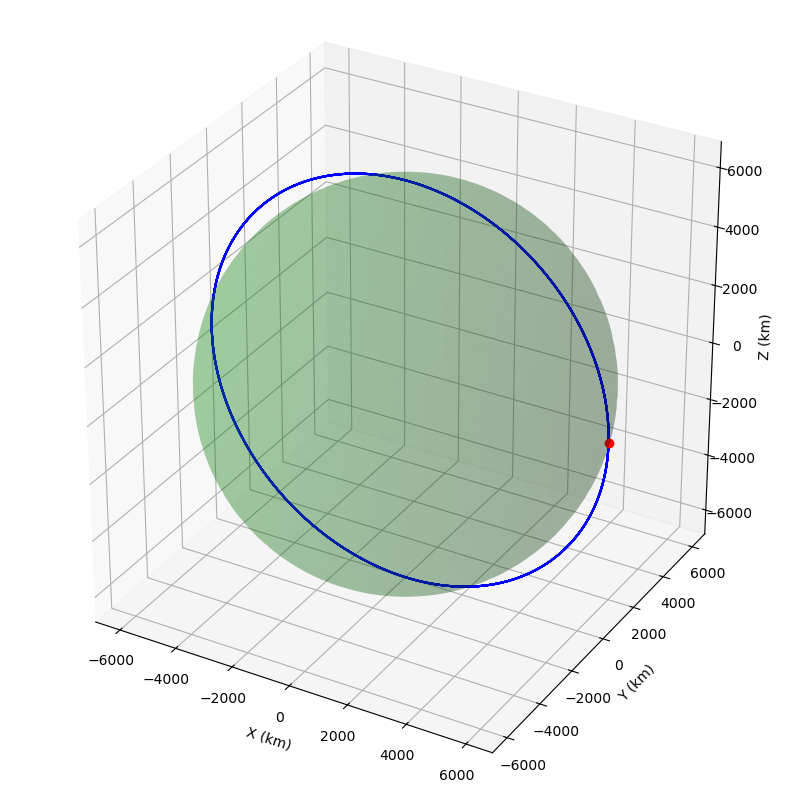

In [58]:
X_SAT = Y[:, 0]
Y_SAT = Y[:, 1]
Z_SAT = Y[:, 2]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
ax.plot(X_SAT, Y_SAT, Z_SAT, color="b")
ax.plot([X_SAT[0]], [Y_SAT[0]], [Z_SAT[0]], color="r", marker="o")


u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)
X_EARTH = R_EARTH * np.outer(np.cos(u), np.sin(v))
Y_EARTH = R_EARTH * np.outer(np.sin(u), np.sin(v))
Z_EARTH = R_EARTH * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(X_EARTH, Y_EARTH, Z_EARTH, color="g", alpha=0.2)

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')

max_val = np.max(np.abs(Y[:, 0:3]))
ax.set_xlim([-max_val, max_val])
ax.set_ylim([-max_val, max_val])
ax.set_zlim([-max_val, max_val])
ax.set_box_aspect([1, 1, 1]) 

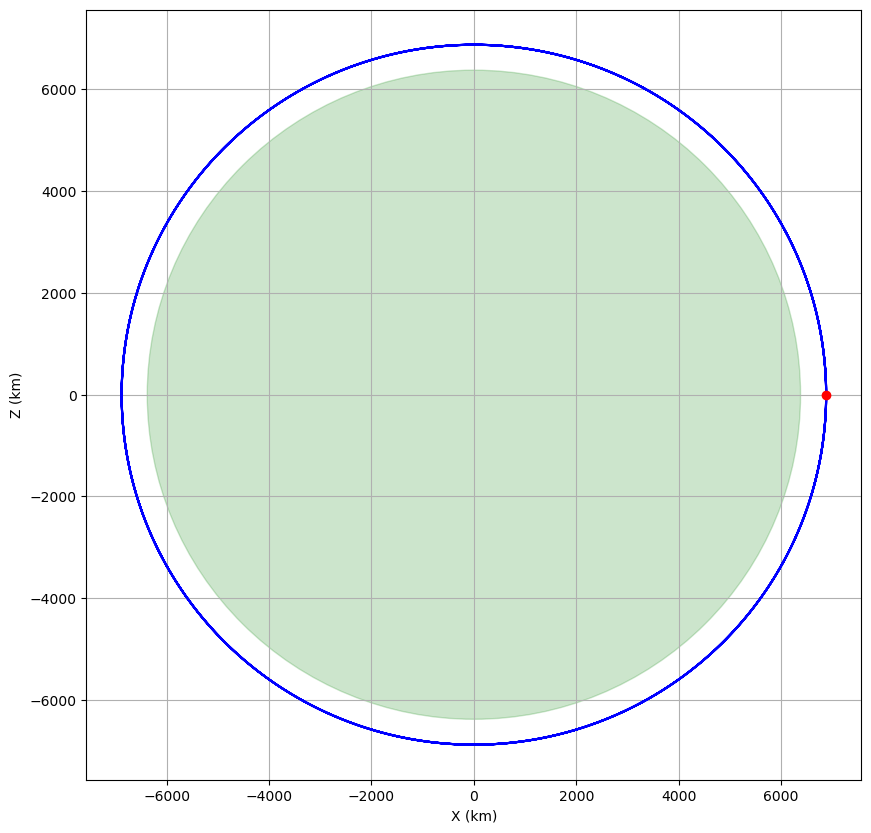

In [59]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(X_SAT, Z_SAT, color="b")
ax.plot(X_SAT[0], Z_SAT[0], marker="o", color="r")
earth2d = patches.Circle((0, 0), R_EARTH, color='g', alpha=0.2)
ax.add_patch(earth2d)
ax.set_xlabel("X (km)")
ax.set_ylabel("Z (km)")
plt.grid()

Text(0.5, 1.0, 'Intermediate Axis Rotation')

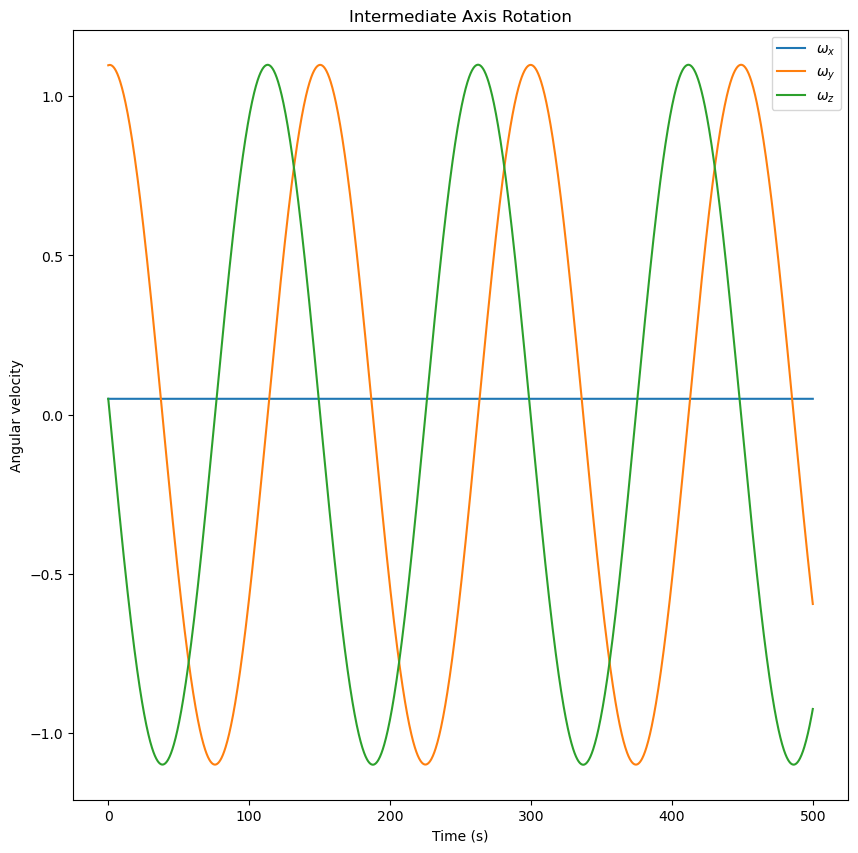

In [93]:
def euler(t, omega, I): 
    return np.linalg.inv(I) @ (-np.cross(omega, I @ omega))

omega_mag = 10*2*np.pi/60
H = IP[2] * omega_mag 

omega_major = np.array([0.0, 0.0, H/IP[2]])
omega_inter = np.array([0.0, H/IP[1], 0.0])
omega_minor = np.array([H/IP[0], 0.0, 0.0])

pertubation = np.array([0.05, 0.05, 0.05])

t_span_att = (0, 500)
t_eval_att = np.linspace(0, 500, 2000)

IPM = np.diag(IP)

omega_major_sol = solve_ivp(euler, t_span_att, omega_major + pertubation, t_eval=t_eval_att, args=(IPM, ))
omega_inter_sol = solve_ivp(euler, t_span_att, omega_inter + pertubation, t_eval=t_eval_att, args=(IPM, ))
omega_minor_sol = solve_ivp(euler, t_span_att, omega_minor + pertubation, t_eval=t_eval_att, args=(IPM, ))

plt.figure(figsize=(10, 10))
plt.plot(t_eval_att, omega_inter_sol.y.T)
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity")
plt.legend([r"$\omega_x$", r"$\omega_y$", r"$\omega_z$"])
plt.title("Intermediate Axis Rotation")




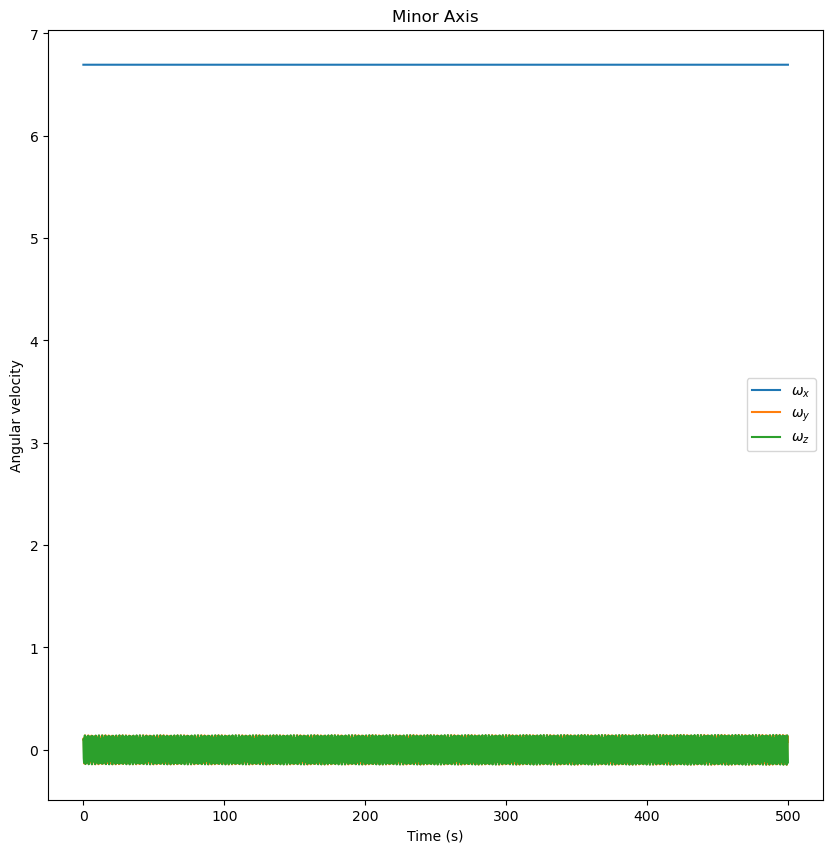

In [91]:
plt.figure(figsize=(10, 10))
plt.plot(t_eval_att, omega_minor_sol.y.T)
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity")
plt.title("Minor Axis")
plt.legend([r"$\omega_x$", r"$\omega_y$", r"$\omega_z$"])

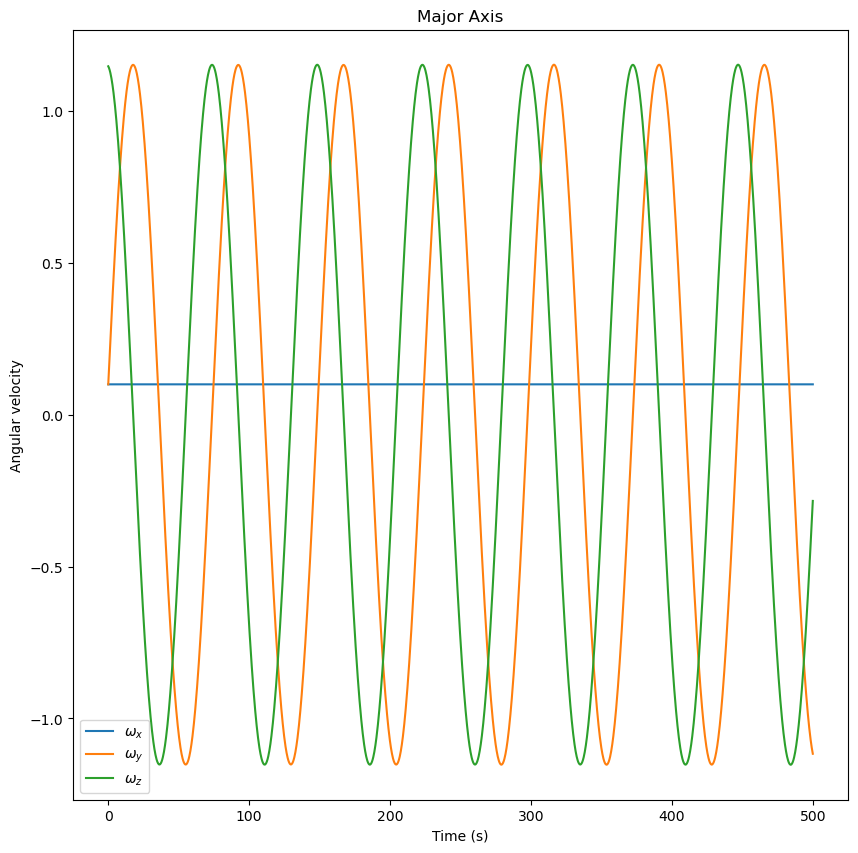

In [90]:
plt.figure(figsize=(10, 10))
plt.plot(t_eval_att, omega_major_sol.y.T)
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity")
plt.title("Major Axis")
plt.legend([r"$\omega_x$", r"$\omega_y$", r"$\omega_z$"])

/tmp/ipykernel_1131/1424917889.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


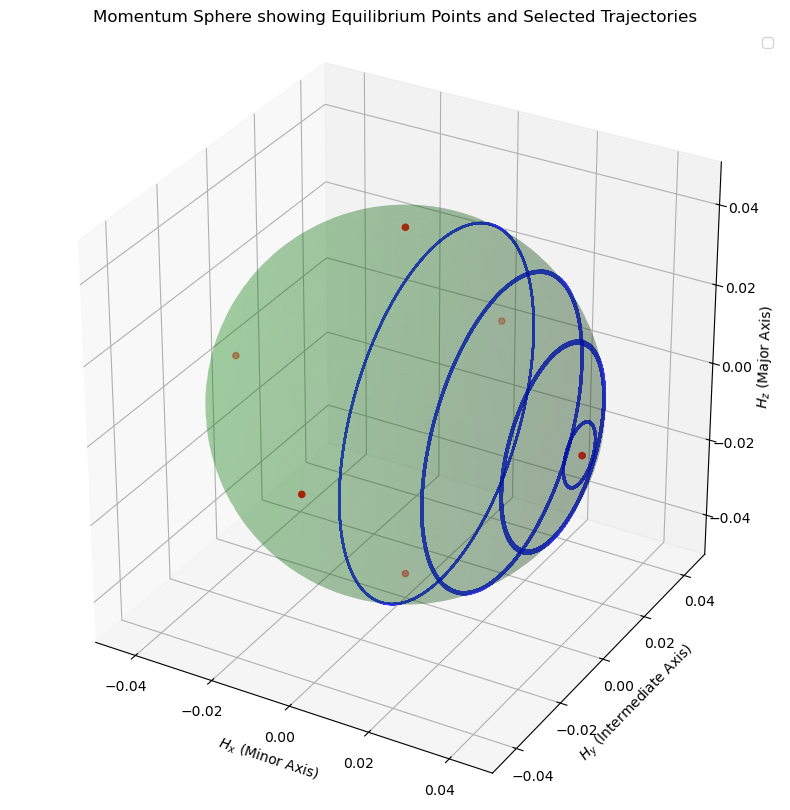

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
X_SPHERE = H * np.outer(np.cos(u), np.sin(v))
Y_SPHERE = H * np.outer(np.sin(u), np.sin(v))
Z_SPHERE = H * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(X_SPHERE, Y_SPHERE, Z_SPHERE, color='g', alpha=0.2)

equilibria = np.array([
    [H, 0, 0], [-H, 0, 0],  
    [0, H, 0], [0, -H, 0],  
    [0, 0, H], [0, 0, -H]  
])

ax.scatter(equilibria[:, 0], equilibria[:, 1], equilibria[:, 2], color='r')

t_span_sphere = (0, 100)
t_eval_sphere = np.linspace(0, 100, 1000)
selected_thetas = [0.2, 0.6, 1.0, 1.4] 

for theta in selected_thetas:
    H0 = np.array([
        H * np.sin(theta) * np.cos(0),
        H * np.sin(theta) * np.sin(0),
        H * np.cos(theta)
    ])
    omega0 = np.linalg.inv(IPM) @ H0
    sol = solve_ivp(euler, t_span_sphere, omega0, t_eval=t_eval_sphere, args=(IPM, ))
    H_traj = IPM @ sol.y
    ax.plot(H_traj[0], H_traj[1], H_traj[2], color='blue', alpha=0.8, linewidth=1.5)

ax.set_xlabel('Minor Axis')
ax.set_ylabel('Intermediate Axis')
ax.set_zlabel('Major Axis')
ax.set_title('Momentum Sphere')
ax.legend()
ax.set_box_aspect([1, 1, 1])